# Importing modules

In [1]:
import sys
sys.path

['/home/umata/anaconda3/envs/GWAD/lib/python311.zip',
 '/home/umata/anaconda3/envs/GWAD/lib/python3.11',
 '/home/umata/anaconda3/envs/GWAD/lib/python3.11/lib-dynload',
 '',
 '/home/umata/anaconda3/envs/GWAD/lib/python3.11/site-packages',
 '/home/umata/anaconda3/envs/GWAD/lib/python3.11/site-packages/setuptools/_vendor']

In [5]:
import os
import numpy as np
import bilby
import argparse
import scipy
import matplotlib.pyplot as plt
import sys
import h5py
import time
import torch

from scipy.stats import cosine as cosine_distribution
from gwpy.timeseries import TimeSeries
from scipy.signal import windows

from scipy.stats import norm

In [4]:
os.getcwd()

'/Users/Liyang_Miao/Library/CloudStorage/OneDrive-HKUSTConnect/Research/GWNMMAD/GWAD/Codes'

In [3]:
os.chdir('D:\OneDrive - HKUST Connect\Research\GWNMMAD\GWAD\Codes')

In [4]:
raw_data_dir = '../Data_cached/Noise_processing/raw_waveform_files/'
trigger_data_dir = '../Data_cached/Noise_processing/Glitch_info/'


In [5]:
STARTING_TIME = 1238166018
ENDING_TIME = 1238170289

In [23]:
STARTING_TIME_L1 = 1238166018
STARTING_TIME_H1 = 1238166018

BANDPASS_LOW = 30
BANDPASS_HIGH = 1500

loaded_starting_time = 0
loaded_ending_time = 3600

segment_freq = 4096
fftlength = 1

segment_length = 4

EVENT_PER_SEGMENT = 10

In [78]:
STARTING_TIME_L1 = 1238362764
STARTING_TIME_H1 = 1238561172 + 15*60

BANDPASS_LOW = 30
BANDPASS_HIGH = 1500

loaded_starting_time = 0 + 30000
loaded_ending_time = 3600 + 30000

segment_freq = 4096
fftlength = 1

segment_length = 4

EVENT_PER_SEGMENT = 10

# Loading the datasets from the GWOSC

In [6]:
os.path.exists(raw_data_dir + 'L-L1_GWOSC_O3a_4KHZ_R1-1238163456-4096.hdf5')

True

In [9]:
os.listdir(raw_data_dir + '60ks/L')

['L-L1_GWOSC_O3a_4KHZ_R1-1238360064-4096.hdf5',
 'L-L1_GWOSC_O3a_4KHZ_R1-1238364160-4096.hdf5',
 'L-L1_GWOSC_O3a_4KHZ_R1-1238368256-4096.hdf5',
 'L-L1_GWOSC_O3a_4KHZ_R1-1238372352-4096.hdf5',
 'L-L1_GWOSC_O3a_4KHZ_R1-1238376448-4096.hdf5',
 'L-L1_GWOSC_O3a_4KHZ_R1-1238380544-4096.hdf5',
 'L-L1_GWOSC_O3a_4KHZ_R1-1238384640-4096.hdf5',
 'L-L1_GWOSC_O3a_4KHZ_R1-1238388736-4096.hdf5',
 'L-L1_GWOSC_O3a_4KHZ_R1-1238392832-4096.hdf5',
 'L-L1_GWOSC_O3a_4KHZ_R1-1238396928-4096.hdf5',
 'L-L1_GWOSC_O3a_4KHZ_R1-1238401024-4096.hdf5',
 'L-L1_GWOSC_O3a_4KHZ_R1-1238405120-4096.hdf5',
 'L-L1_GWOSC_O3a_4KHZ_R1-1238409216-4096.hdf5',
 'L-L1_GWOSC_O3a_4KHZ_R1-1238413312-4096.hdf5',
 'L-L1_GWOSC_O3a_4KHZ_R1-1238417408-4096.hdf5',
 'L-L1_GWOSC_O3a_4KHZ_R1-1238421504-4096.hdf5',
 'L-L1_GWOSC_O3a_4KHZ_R1-1238425600-4096.hdf5']

In [7]:
dataset_L = TimeSeries.read(source = [raw_data_dir + 'L-L1_GWOSC_O3a_4KHZ_R1-1238163456-4096.hdf5', raw_data_dir + 'L-L1_GWOSC_O3a_4KHZ_R1-1238167552-4096.hdf5'], format="hdf5.gwosc", start=STARTING_TIME, end=ENDING_TIME)

C:\Users\Liyang Miao\AppData\Local\Programs\Python\Python311\Lib\site-packages\gwpy\types\series.py:991: UserWarning: TimeSeries.crop given end larger than current end, crop will begin when the Series actually ends.
  warn(
C:\Users\Liyang Miao\AppData\Local\Programs\Python\Python311\Lib\site-packages\gwpy\types\series.py:981: UserWarning: TimeSeries.crop given start smaller than current start, crop will begin when the Series actually starts.
  warn(


In [8]:
dataset_H = TimeSeries.read(source = [raw_data_dir + 'H-H1_GWOSC_O3a_4KHZ_R1-1238163456-4096.hdf5', raw_data_dir + 'H-H1_GWOSC_O3a_4KHZ_R1-1238167552-4096.hdf5'], format="hdf5.gwosc", start=STARTING_TIME, end=ENDING_TIME)

In [79]:
dataset_L = TimeSeries.read(source = [raw_data_dir + '60ks/L/' + file for file in os.listdir(raw_data_dir + '60ks/L')], format="hdf5.gwosc", start=STARTING_TIME_L1+loaded_starting_time, end=STARTING_TIME_L1+loaded_ending_time)
dataset_H = TimeSeries.read(source = [raw_data_dir + '60ks/H/' + file for file in os.listdir(raw_data_dir + '60ks/H')], format="hdf5.gwosc", start=STARTING_TIME_H1+loaded_starting_time, end=STARTING_TIME_H1+loaded_ending_time)

In [6]:
dataset_L = TimeSeries.read(source = [raw_data_dir + '23ks/L/' + file for file in os.listdir(raw_data_dir + '23ks/L')], format="hdf5.gwosc", start=STARTING_TIME_L1+loaded_starting_time, end=STARTING_TIME_L1+loaded_ending_time)
dataset_H = TimeSeries.read(source = [raw_data_dir + '23ks/H/' + file for file in os.listdir(raw_data_dir + '23ks/H')], format="hdf5.gwosc", start=STARTING_TIME_H1+loaded_starting_time, end=STARTING_TIME_H1+loaded_ending_time)

C:\Users\Liyang Miao\AppData\Local\Programs\Python\Python311\Lib\site-packages\gwpy\types\series.py:991: UserWarning: TimeSeries.crop given end larger than current end, crop will begin when the Series actually ends.
  warn(
C:\Users\Liyang Miao\AppData\Local\Programs\Python\Python311\Lib\site-packages\gwpy\types\series.py:981: UserWarning: TimeSeries.crop given start smaller than current start, crop will begin when the Series actually starts.
  warn(


In [9]:
dataset_L.span

Segment(1238166018.0, 1238170289.0)

In [10]:
dataset_L.info()

dtype = float64
class = TimeSeries
n_bad = 1
length = 17494016


In [11]:
dataset_H.info()

dtype = float64
class = TimeSeries
n_bad = 1
length = 17494016


In [10]:
dataset_L.sample_rate

<Quantity 4096. Hz>

In [12]:
dataset_L.span

Segment(1238402764.0, 1238406364.0)

In [13]:
dataset_H.span

Segment(1238601172.0, 1238604772.0)

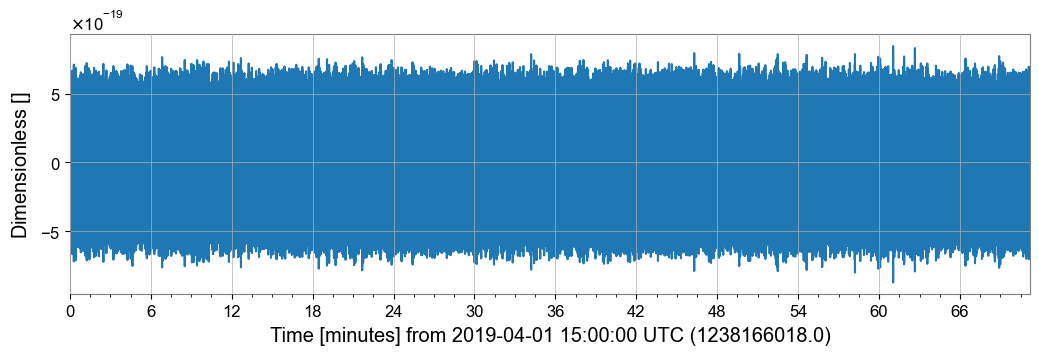

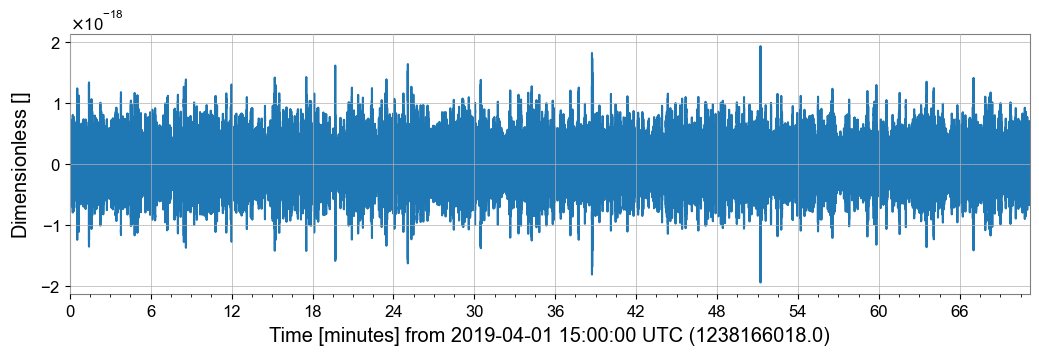

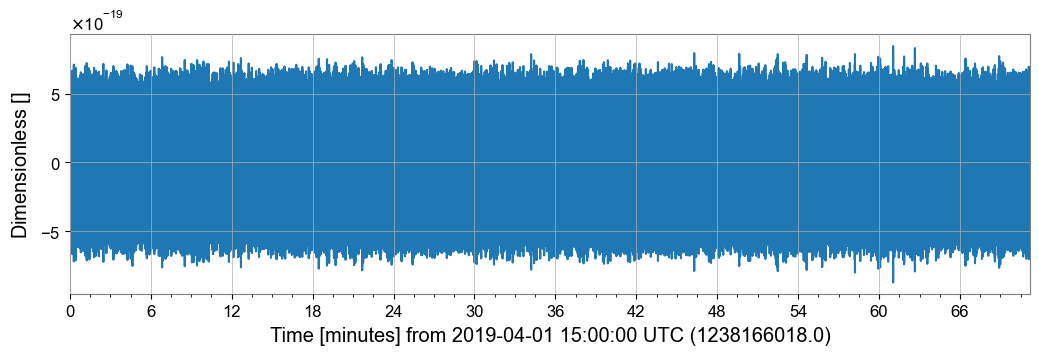

In [8]:
dataset_L.plot()
dataset_H.plot()

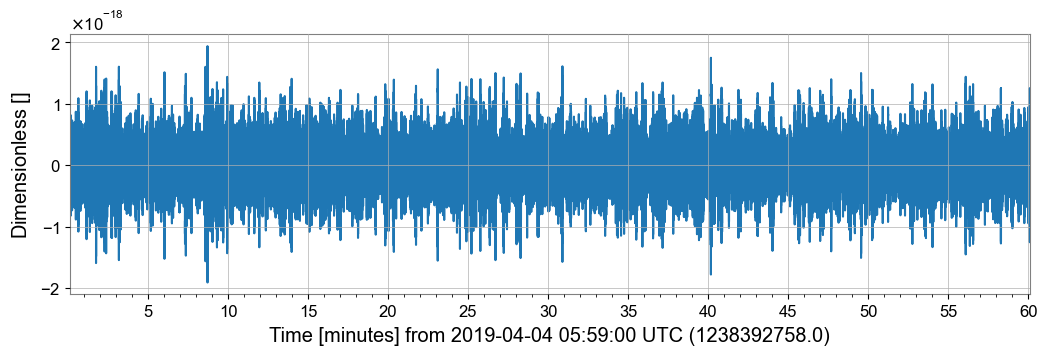

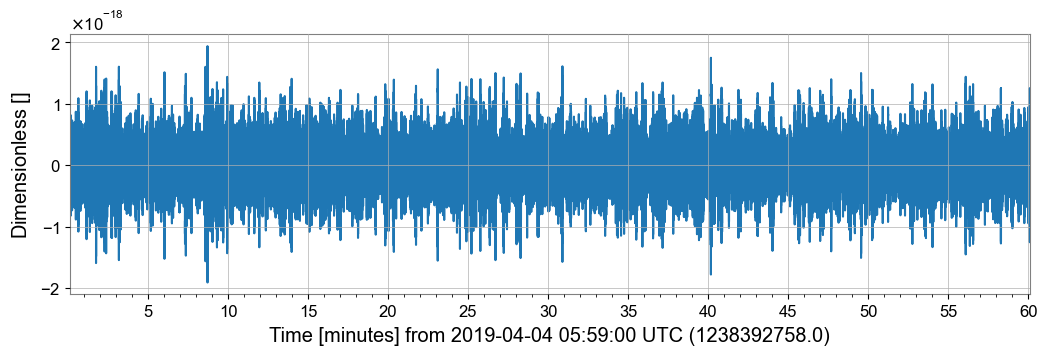

In [7]:
dataset_L.plot()

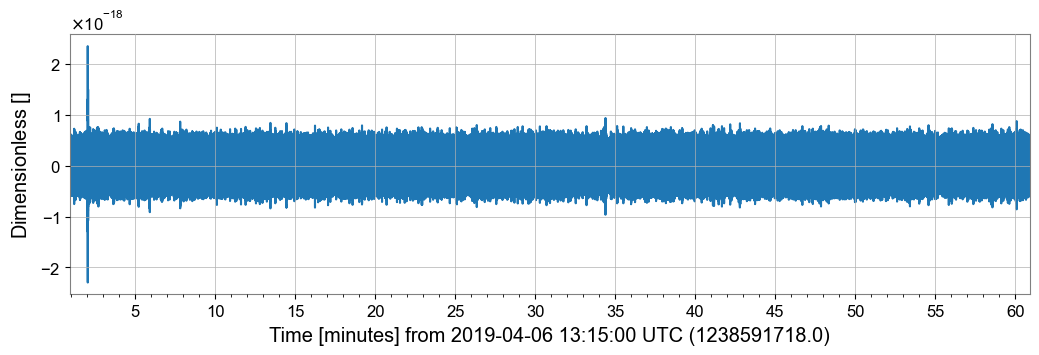

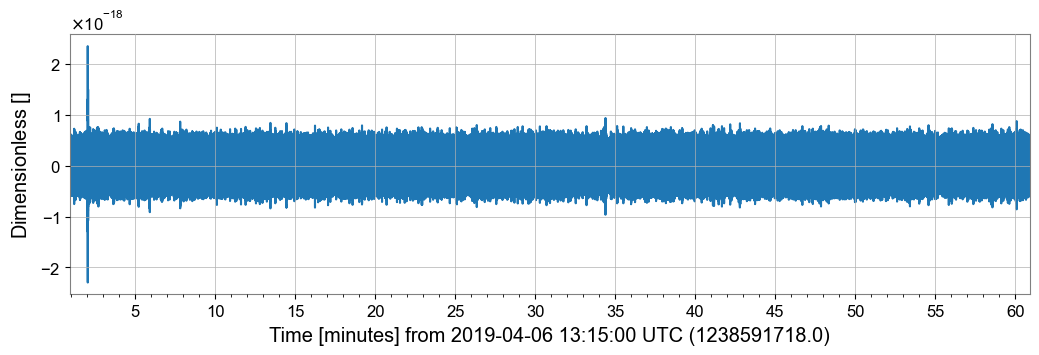

In [47]:
dataset_H.plot()

## How about the GWAK set used to give us? what are they

# Try to process the noise. Using a GWAK-like scheme

## Defind some hyperparameter

## First, compute the asd of the dataset. Here we only use the first 3600s of the dataset

In [12]:
dataset_L.t0.value

1238166018.0

In [13]:
dataset_L = dataset_L.crop(dataset_L.t0.value + loaded_starting_time, dataset_L.t0.value + loaded_ending_time)

In [14]:
dataset_L.span

Segment(1238166018.0, 1238169618.0)

In [15]:
dataset_H = dataset_H.crop(dataset_H.t0.value + loaded_starting_time, dataset_H.t0.value + loaded_ending_time)

In [16]:
dataset_H.span

Segment(1238166018.0, 1238169618.0)

In [17]:
dataset_asd_L = dataset_L.asd(
                                fftlength=fftlength,
                                overlap=0,
                                method='welch',
                                window='hann')
dataset_asd_H = dataset_H.asd(
                                fftlength=fftlength,
                                overlap=0,
                                method='welch',
                                window='hann')

1

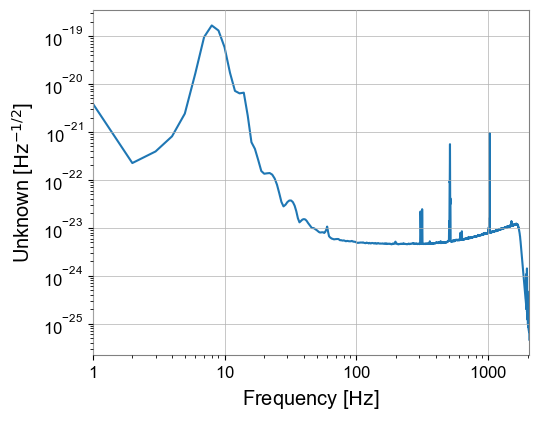

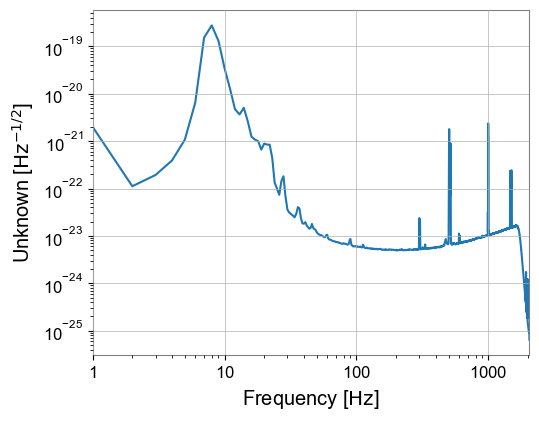

In [9]:
dataset_asd_L.plot()
dataset_asd_H.plot()
1

1

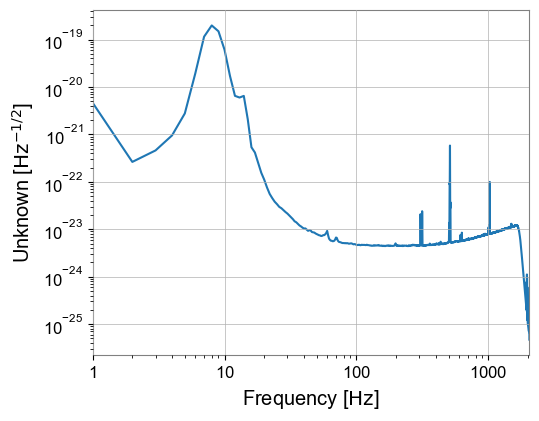

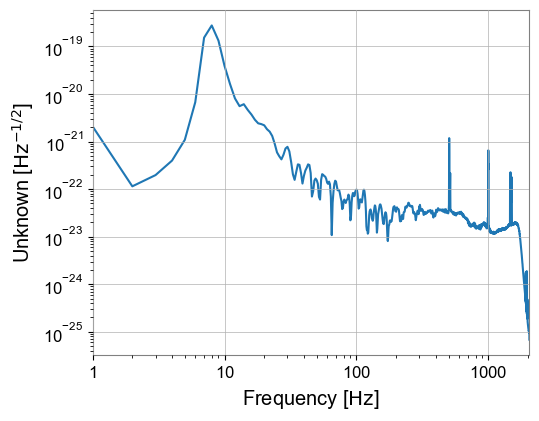

In [49]:
dataset_asd_L.plot()
dataset_asd_H.plot()
1

1

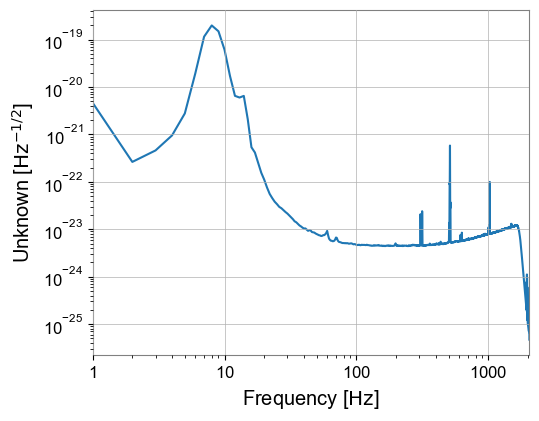

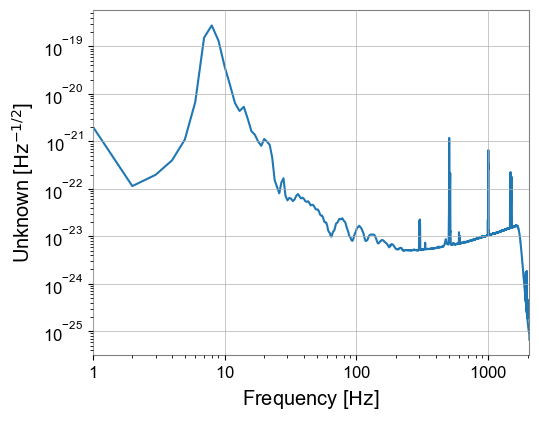

In [16]:
dataset_asd_L.plot()
dataset_asd_H.plot()
1

In [60]:
type(dataset_asd_L)

gwpy.frequencyseries.frequencyseries.FrequencySeries

In [86]:
dataset_asd_L.xspan

Segment(0.0, 2049.0)

In [89]:
dataset_asd_L.info

dtype = float64
unit = 1 / Hz(1/2)
class = FrequencySeries
n_bad = 0
length = 2049

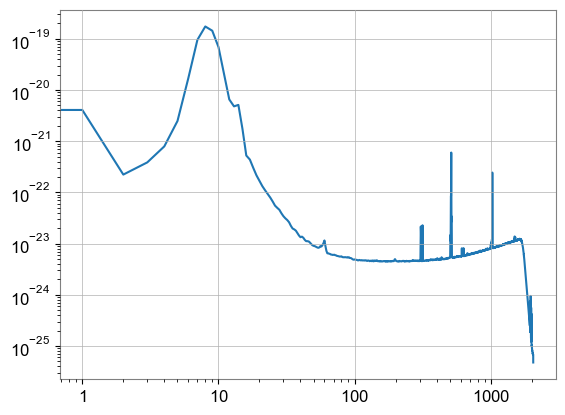

In [23]:
plt.plot(dataset_asd_L.value)
plt.xscale('log')
plt.yscale('log')

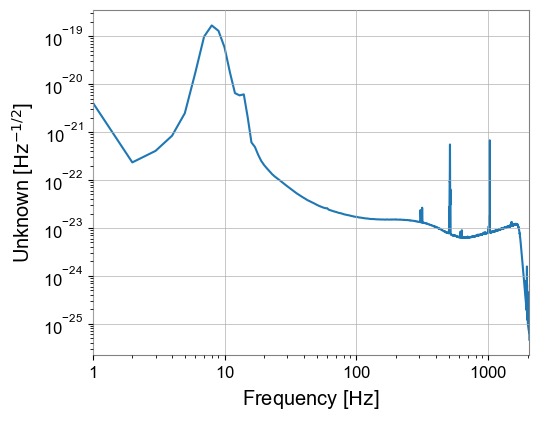

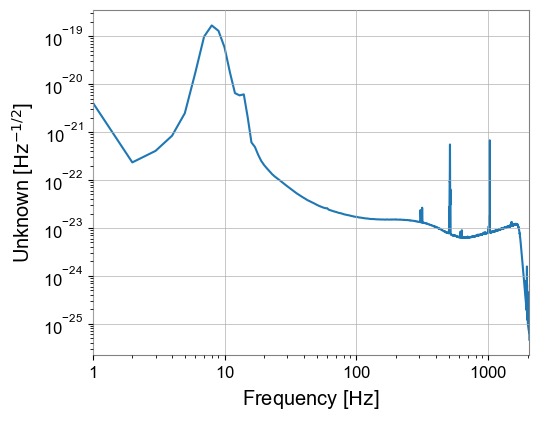

In [57]:
dataset_asd_L.plot()

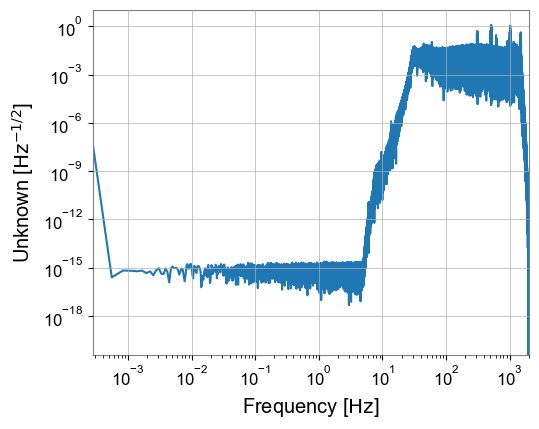

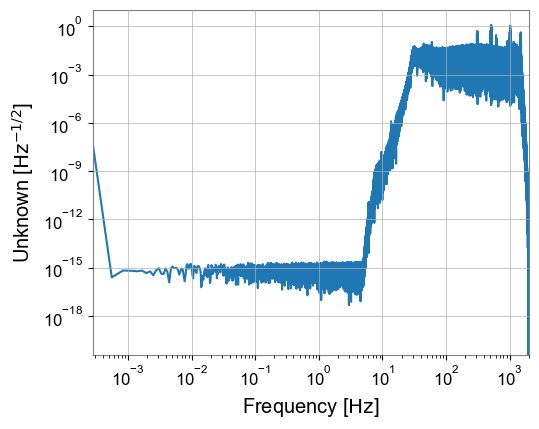

In [28]:
dataset_L.whiten(asd = dataset_asd_L).bandpass(30,1500).asd().plot()

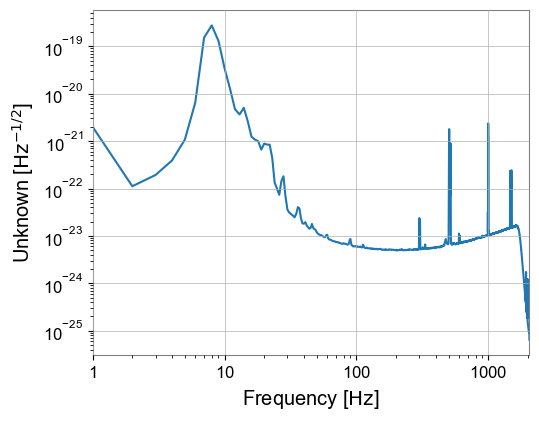

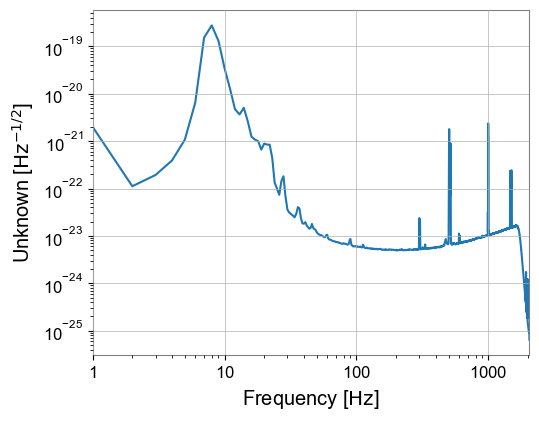

In [39]:
dataset_asd_H.plot()

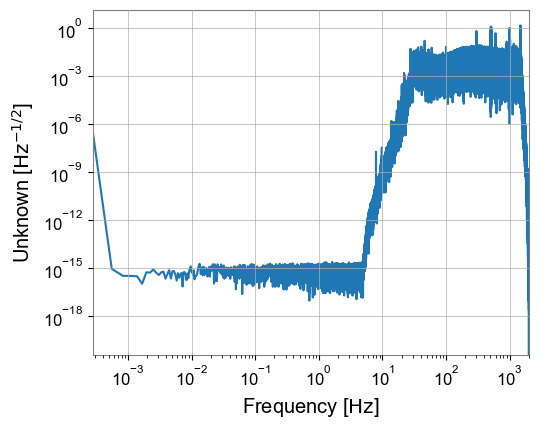

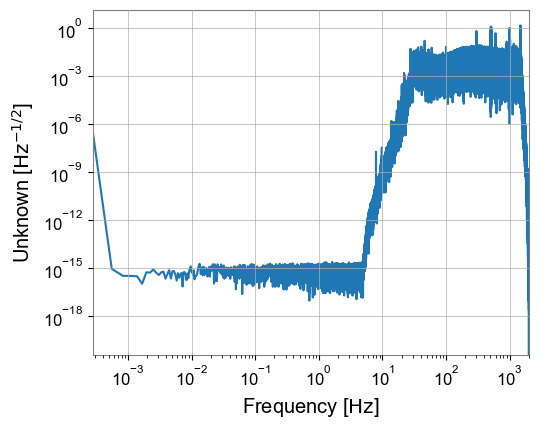

In [27]:
dataset_H.whiten(asd = dataset_asd_H).bandpass(30,1500).asd().plot()

## Removing the glitches and find proper window for noise events to exist

In [18]:
glitch_trigger_time_L = np.load(trigger_data_dir + 'Glitch_time_L_4271s_727.npy')
glitch_trigger_time_H = np.load(trigger_data_dir + 'Glitch_time_H_4271s_387.npy')

In [29]:
glitch_trigger_time_L = np.load(trigger_data_dir + 'Glitch_time_L_63917s_7878.npy')
glitch_trigger_time_H = np.load(trigger_data_dir + 'Glitch_time_H_58803s_6424.npy')

In [19]:
glitch_trigger_time_L

array([1.23816603e+09, 1.23816604e+09, 1.23816605e+09, ...,
       1.23817025e+09, 1.23817026e+09, 1.23817028e+09])

In [24]:
glitch_trigger_starting_time_L = np.maximum(STARTING_TIME_L1 + loaded_starting_time, glitch_trigger_time_L - 6)
glitch_trigger_ending_time_L = np.minimum(STARTING_TIME_L1 + loaded_ending_time, glitch_trigger_time_L + 2)

glitch_trigger_starting_time_H = np.maximum(STARTING_TIME_H1 + loaded_starting_time, glitch_trigger_time_H - 6)
glitch_trigger_ending_time_H = np.minimum(STARTING_TIME_H1 + loaded_ending_time, glitch_trigger_time_H + 2)

In [25]:
STARTING_TIME_L1

1238166018

In [26]:
glitch_trigger_time_L.min()

1238166031.027343

In [27]:
glitch_trigger_starting_time_L.min()

1238166025.027343

In [28]:
proper_starting_time = np.arange(STARTING_TIME, STARTING_TIME + loaded_ending_time - segment_length, 1/50)

In [29]:
proper_starting_time.shape

(179800,)

In [30]:
args_L = np.ones(len(proper_starting_time))
args_H = np.ones(len(proper_starting_time))

In [31]:
bottom_idx_L = np.searchsorted(proper_starting_time, glitch_trigger_starting_time_L)
top_idx_L = np.searchsorted(proper_starting_time, glitch_trigger_ending_time_L)

In [32]:
bottom_idx_L

array([   352,    970,   1243, ..., 179800, 179800, 179800],
      dtype=int64)

In [33]:
top_idx_L

array([   752,   1370,   1643, ..., 179800, 179800, 179800],
      dtype=int64)

In [34]:
for i in range(len(bottom_idx_L)):
    args_L[bottom_idx_L[i]:top_idx_L[i]] = np.zeros((top_idx_L[i] - bottom_idx_L[i]))

In [35]:
bottom_idx_H = np.searchsorted(proper_starting_time, glitch_trigger_starting_time_H)
top_idx_H = np.searchsorted(proper_starting_time, glitch_trigger_ending_time_H)

In [36]:
for i in range(len(bottom_idx_H)):
    args_H[bottom_idx_H[i]:top_idx_H[i]] = np.zeros((top_idx_H[i] - bottom_idx_H[i]))

In [37]:
args_L.shape

(179800,)

In [38]:
args_L = (args_L != 0)

In [39]:
args_H = (args_H != 0)

In [40]:
proper_starting_time_L = proper_starting_time[args_L]
proper_starting_time_H = proper_starting_time[args_H]

In [41]:
proper_starting_time_combined = np.intersect1d(proper_starting_time_H, proper_starting_time_L)

In [42]:
proper_starting_time_combined.shape

(22037,)

(array([2343., 2848., 2242., 2069., 2143., 2271.,  654., 2750.,
        2444., 2273.]),
 array([1.23816602e+09, 1.23816638e+09, 1.23816674e+09,
        1.23816710e+09, 1.23816746e+09, 1.23816781e+09,
        1.23816817e+09, 1.23816853e+09, 1.23816889e+09,
        1.23816925e+09, 1.23816961e+09]),
 <BarContainer object of 10 artists>)

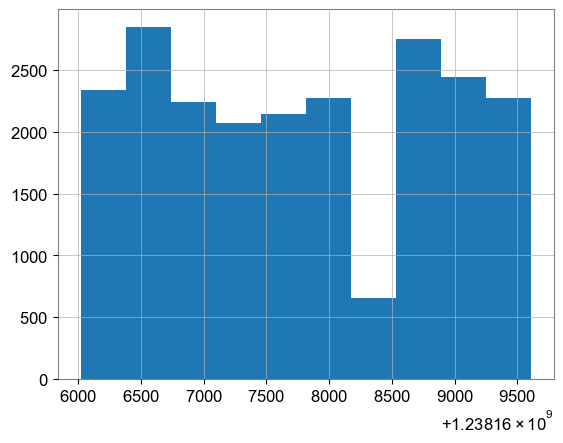

In [51]:
plt.hist(proper_starting_time_combined)

## Removing the glitches and find proper window for noise events to exist (Separated window version)

In [ ]:
glitch_trigger_time_L = np.load(trigger_data_dir + 'Glitch_time_L_4271s_727.npy')
glitch_trigger_time_H = np.load(trigger_data_dir + 'Glitch_time_H_4271s_387.npy')

In [10]:
glitch_trigger_time_L = np.load(trigger_data_dir + 'Glitch_time_L_23812s_2588.npy')
glitch_trigger_time_H = np.load(trigger_data_dir + 'Glitch_time_H_23806s_2283.npy')

In [50]:
glitch_trigger_time_L = np.load(trigger_data_dir + 'Glitch_time_L_63917s_7878.npy')
glitch_trigger_time_H = np.load(trigger_data_dir + 'Glitch_time_H_58803s_6424.npy')

In [11]:
glitch_trigger_time_L

array([1.23820509e+09, 1.23820509e+09, 1.23820509e+09, ...,
       1.23822884e+09, 1.23822884e+09, 1.23822887e+09])

In [11]:
glitch_trigger_starting_time_L = np.maximum(STARTING_TIME_L1 + loaded_starting_time, glitch_trigger_time_L - 6)
glitch_trigger_ending_time_L = np.minimum(STARTING_TIME_L1 + loaded_ending_time, glitch_trigger_time_L + 2)

glitch_trigger_starting_time_H = np.maximum(STARTING_TIME_H1 + loaded_starting_time, glitch_trigger_time_H - 6)
glitch_trigger_ending_time_H = np.minimum(STARTING_TIME_H1 + loaded_ending_time, glitch_trigger_time_H + 2)

In [ ]:
STARTING_TIME_L1

1238362764

In [ ]:
glitch_trigger_time_L.min()

1238362770.445312

In [ ]:
glitch_trigger_starting_time_L.min()

1238362764.445312

In [12]:
proper_starting_time_L = np.arange(STARTING_TIME_L1+loaded_starting_time, STARTING_TIME_L1 + loaded_ending_time - segment_length, 1/50)
proper_starting_time_H = np.arange(STARTING_TIME_H1+loaded_starting_time, STARTING_TIME_H1 + loaded_ending_time - segment_length, 1/50)

In [26]:
proper_starting_time.shape

NameError: name 'proper_starting_time' is not defined

In [13]:
args_L = np.ones(len(proper_starting_time_L))
args_H = np.ones(len(proper_starting_time_H))

In [14]:
bottom_idx_L = np.searchsorted(proper_starting_time_L, glitch_trigger_starting_time_L)
top_idx_L = np.searchsorted(proper_starting_time_L, glitch_trigger_ending_time_L)

In [15]:
bottom_idx_L

array([     0,      0,      0, ..., 179800, 179800, 179800],
      dtype=int64)

In [16]:
top_idx_L

array([     0,      0,      0, ..., 179800, 179800, 179800],
      dtype=int64)

In [17]:
for i in range(len(bottom_idx_L)):
    args_L[bottom_idx_L[i]:top_idx_L[i]] = np.zeros((top_idx_L[i] - bottom_idx_L[i]))

In [18]:
bottom_idx_H = np.searchsorted(proper_starting_time_H, glitch_trigger_starting_time_H)
top_idx_H = np.searchsorted(proper_starting_time_H, glitch_trigger_ending_time_H)

In [19]:
for i in range(len(bottom_idx_H)):
    args_H[bottom_idx_H[i]:top_idx_H[i]] = np.zeros((top_idx_H[i] - bottom_idx_H[i]))

In [20]:
args_L.shape

(179800,)

In [21]:
args_L = (args_L != 0)

In [22]:
args_H = (args_H != 0)

In [23]:
proper_starting_time_L = proper_starting_time_L[args_L]
proper_starting_time_H = proper_starting_time_H[args_H]

In [24]:
proper_starting_time_L.shape

(73015,)

## Pick from the proper starting time

In [43]:
proper_starting_time_picked = proper_starting_time_combined[np.random.choice(len(proper_starting_time_combined), 10000, replace=False)]

In [44]:
proper_starting_time_picked.shape

(10000,)

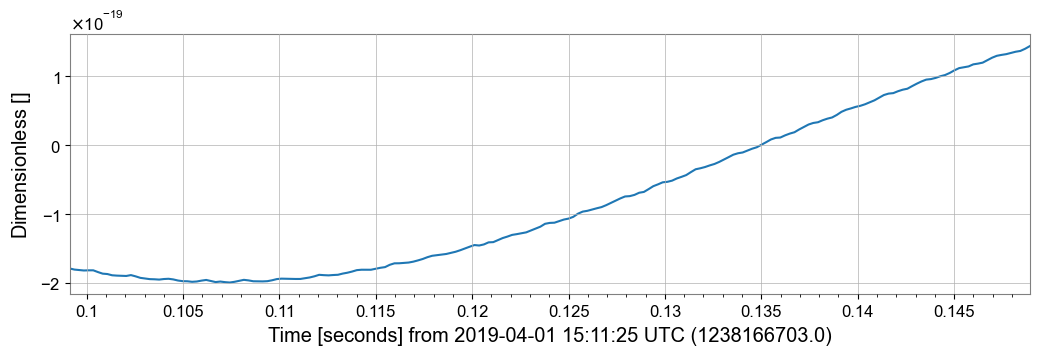

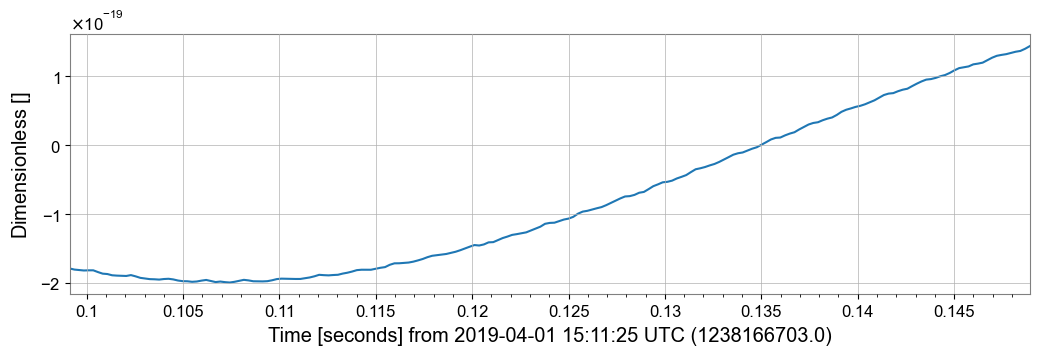

In [45]:
dataset_L.crop(proper_starting_time_picked[0], proper_starting_time_picked[0]+0.05).plot()

In [46]:
dataset_L.span

Segment(1238166018.0, 1238169618.0)

In [47]:
np.save('../Data_cached/Noise_processing/Glitch_info/noise_segment_time_picked_v1.npy', proper_starting_time_picked)

## Pick from the proper starting time

In [25]:
proper_starting_time_picked_L = proper_starting_time_L[np.random.choice(len(proper_starting_time_L), 10000, replace=False)]
proper_starting_time_picked_H = proper_starting_time_H[np.random.choice(len(proper_starting_time_H), 10000, replace=False)]

In [26]:
proper_starting_time_picked_L.shape

(10000,)

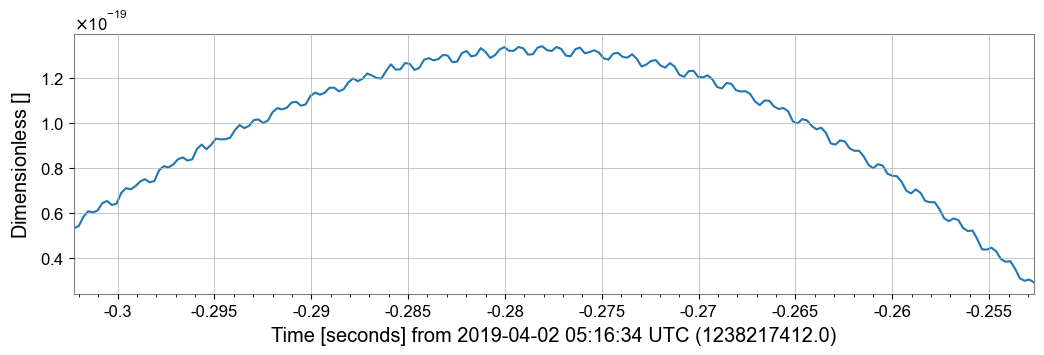

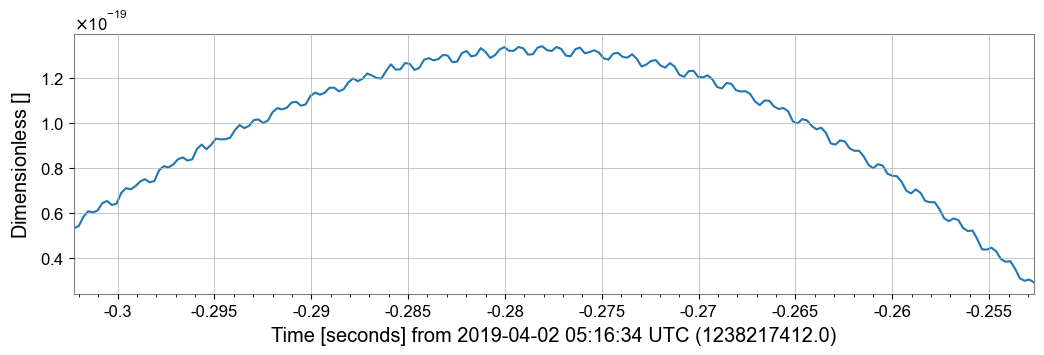

In [27]:
dataset_L.crop(proper_starting_time_picked_L[0], proper_starting_time_picked_L[0]+0.05).plot()

In [ ]:
dataset_L.span

Segment(1238166018.0, 1238169618.0)

In [28]:
np.savez('../Data_cached/Noise_processing/Glitch_info/noise_segment_time_picked_v4_4.npz', starting_time_L = proper_starting_time_picked_L, starting_time_H = proper_starting_time_picked_H)

## Finally, using the asd to whiten the data and save the segments

In [29]:
segments_noise_whitened = np.empty((10000,2,8192))

for i in range(len(proper_starting_time_picked_L)):
    dataset_picked_L = dataset_L.crop(proper_starting_time_picked_L[i], proper_starting_time_picked_L[i]+segment_length)
    dataset_picked_H = dataset_H.crop(proper_starting_time_picked_H[i], proper_starting_time_picked_H[i]+segment_length)
    
    dataset_picked_L = dataset_picked_L.whiten(asd=dataset_asd_L).bandpass(BANDPASS_LOW, BANDPASS_HIGH)
    dataset_picked_H = dataset_picked_H.whiten(asd=dataset_asd_H).bandpass(BANDPASS_LOW, BANDPASS_HIGH)
    
    segments_noise_whitened[i,0] = dataset_picked_H.value[4096:-4096]
    segments_noise_whitened[i,1] = dataset_picked_L.value[4096:-4096]

In [65]:
dataset_picked_L.span

Segment(1238394106.0185547, 1238394110.0185547)

In [147]:
segments_noise_whitened

array([[[ 1.33079144e+00,  9.45977734e-01,  6.04286594e-01,
         ..., -2.52051591e-01, -5.26886406e-01,
         -3.48564970e-01],
        [-2.13374055e+00,  8.48788826e-01, -3.62799859e-01,
         ..., -2.73257663e-02, -8.20239459e-01,
          1.73646333e-01]],

       [[ 2.67498153e-01,  9.48043397e-01, -1.35344821e-01,
         ...,  9.47980095e-02,  9.29711432e-01,
         -1.19046387e-01],
        [ 1.18396355e-01, -2.06337237e+00, -6.83267197e-02,
         ...,  6.35329899e-01, -6.63787973e-01,
          4.29268551e-01]],

       [[-1.30536038e-01, -1.40573028e+00, -7.43991323e-01,
         ..., -6.08036184e-01,  9.56108940e-01,
         -3.06325512e-02],
        [-1.68394614e+00,  7.76766649e-01,  1.80772908e-01,
         ...,  1.01066664e+00, -7.07456051e-01,
          6.05203404e-01]],

       ...,

       [[-5.13109615e-01,  2.24683978e-01,  3.13402173e-02,
         ...,  1.33772248e+00,  4.26002054e-01,
          1.87205031e-01],
        [ 1.61186291e+00,  1.7357556

In [30]:
segments_noise_whitened.shape

(10000, 2, 8192)

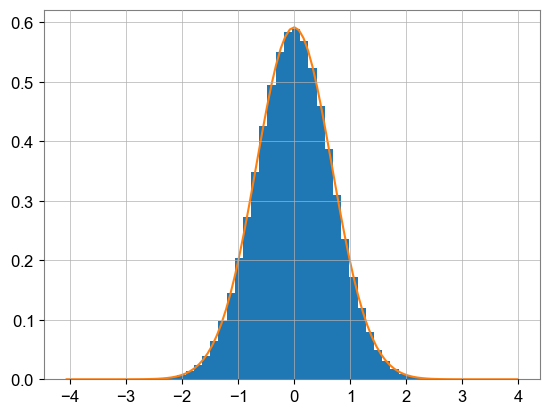

In [31]:
dataset = segments_noise_whitened[:,:,:].flatten()

plt.hist(dataset, bins = 50, density = True)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, np.mean(dataset), np.std(dataset))

plt.plot(x,p)

In [32]:
np.save('../Data_cached/Noise_processing/Processed_segments/noise_segments_v4_4.npy', segments_noise_whitened)

In [7]:
segments_noise_whitened = np.load('../Data_cached/Noise_processing/Processed_segments/noise_segments_v0.npy')

In [33]:
del dataset_L, dataset_H

In [34]:
segments_noise_whitened.shape

(10000, 2, 8192)

## Cut out 200 timewindow events

In [35]:
noise_events = np.empty((len(segments_noise_whitened),EVENT_PER_SEGMENT,2,200))

for i in range(len(segments_noise_whitened)):
# for i in range(1):
    for j in range(EVENT_PER_SEGMENT):
        starting_time = np.random.choice(segment_freq * (segment_length-2) -200, 1, replace = False)
        ending_time = starting_time + 200
        
        cache = segments_noise_whitened[i][:,starting_time[0]:ending_time[0]]
    
        noise_events[i,j] = cache.copy()

In [72]:
segments_noise_whitened.shape

(10000, 2, 8192)

In [40]:
starting_time

array([5191])

In [41]:
ending_time

array([5391])

In [36]:
cache.shape

NameError: name 'cache' is not defined

In [73]:
noise_events.shape

(10000, 10, 2, 200)

In [36]:
noise_events = noise_events.reshape(-1,2,200)

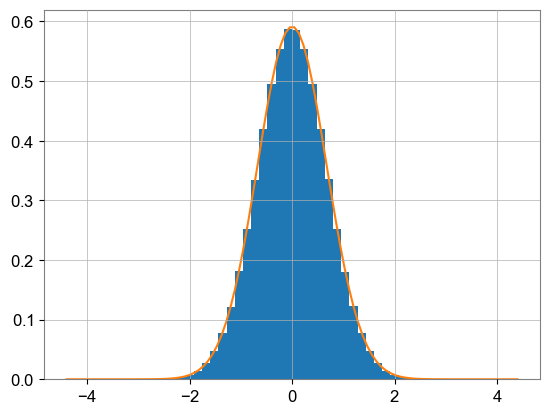

In [37]:
dataset = noise_events.flatten()

plt.hist(dataset, bins = 50, range = (-4,4), density = True)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, np.mean(dataset), np.std(dataset))

plt.plot(x,p)

In [38]:
np.random.shuffle(noise_events)

In [39]:
np.save('../Data_cached/Noise_processing/Processed_noise_sets/noise_sets_v4_4.npy',noise_events)

# Now let's see can we reproduce the signal events or not

## We now have the noise segment cutted out. Note here that they are not whitened

In [393]:
noise_segment_times = np.load('../Data_cached/Noise_processing/Processed_segments/noise_segments_v1.npy')

In [395]:
noise_segment_times.shape

(10000, 2, 8192)

In [396]:
noise_segment_times = np.load('../Data_cached/Noise_processing/Glitch_info/noise_segment_time_picked_v1.npz')

In [397]:
noise_segment_times.shape

(100000, 2, 200)

In [49]:
segment_length

4

In [51]:
proper_starting_time_combined.shape

(22037,)

In [53]:
segments_noise = np.empty((10000,2,8192 * 2))

for i in range(len(proper_starting_time_picked)):
    segments_noise[i,1] = dataset_L.crop(proper_starting_time_picked[i], proper_starting_time_picked[i]+segment_length)
    segments_noise[i,0] = dataset_H.crop(proper_starting_time_picked[i], proper_starting_time_picked[i]+segment_length)

## Simulating the signals and injecting them into the noise waveform

In [58]:
segments_noise.shape

(10000, 2, 16384)

In [59]:
np.save('../Data_cached/Noise_processing/Noise_for_injection/noise_for_inj_v1.npy', segments_noise)

In [ ]:
bkg_segs = np.load('../Data_cached/Noise_processing/Noise_for_injection/noise_for_inj_v1.npy')

In [55]:
n_injections = 10000

SAMPLE_RATE = 4096
EDGE_INJECT_SPACING = 1.2

IFOS = ['H1', 'L1']

In [57]:
bbh_waveform_args = dict(waveform_approximant='IMRPhenomPv2',
                             reference_frequency=50., minimum_frequency=20.)
waveform = bilby.gw.source.lal_binary_black_hole
waveform_generator = bilby.gw.WaveformGenerator(
    duration=segment_length,
    sampling_frequency=4096,
    frequency_domain_source_model=waveform,
    waveform_arguments=bbh_waveform_args
)

priors = bilby.gw.prior.BBHPriorDict()
injection_parameters = priors.sample(n_injections)
injection_parameters = [
    dict(zip(injection_parameters, col))
    for col in zip(*injection_parameters.values())
]
# if specified_params is not None:
#     # set for all elements
#     for param in specified_params: #key
#         for inj_param in injection_parameters:
#             inj_param[param] = specified_params[param]


for i, p in enumerate(injection_parameters):
    dist = np.random.uniform(50, 200)
    p['luminosity_distance'] = dist

crosses = []
plusses = []
for i, p in enumerate(injection_parameters):
    p['geocent_time'] = 0
    pols = waveform_generator.time_domain_strain(p)
    cross = pols['cross']
    plus = pols['plus']

    crosses.append(cross)
    plusses.append(plus)

crosses = np.vstack(crosses)
plusses = np.vstack(plusses)

half = crosses.shape[1] // 2

crosses = np.hstack([crosses[:, half:], crosses[:, :half]])
plusses = np.hstack([plusses[:, half:], plusses[:, :half]])

14:38 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
14:38 bilby INFO    : No prior given, using default BBH priors in C:\Users\Liyang Miao\AppData\Local\Programs\Python\Python311\Lib\site-packages\bilby\gw\prior_files\precessing_spins_bbh.prior.


ModuleNotFoundError: No module named 'lal'

In [ ]:
def calc_psd(
        data,
        df,
        fftlength=2):
    # heavily inspired by
    # https://github.com/ML4GW/ml4gw/blob/main/ml4gw/spectral.py
    default_psd_kwargs = dict(method='median', window='hann')
    x = data.psd(fftlength, **default_psd_kwargs)
    if x.df.value != df:
        x = x.interpolate(df)

    return x.value


def calc_SNR_new(
        datae,
        detec_data,
        fs,
        detector_psds=None,
        return_psds=False):
    # heavily inspired by:
    # https://github.com/ML4GW/ml4gw/blob/main/ml4gw/gw.py
    snr_tot = np.zeros(datae.shape[1])
    if return_psds:
        save_psds = dict()
    for ifo_num, ifo in enumerate(IFOS):
        data = datae[ifo_num]
        df = fs / data.shape[-1]
        single_detec_data = detec_data[ifo]['data']

        fft_of_template = np.fft.rfft(data)
        fft_of_template = np.abs(fft_of_template) / fs
        # calculate detector psd

        if detector_psds is None:
            # this is the desired df value
            detec_psd = calc_psd(single_detec_data, df)
        else:
            detec_psd = detector_psds[ifo]
        if return_psds:
            save_psds[ifo] = detec_psd
        fft_data = fft_of_template
        integrand = fft_data / detec_psd ** 0.5
        integrand = integrand ** 2

        integrated = integrand.sum(axis=-1) * df
        integrated = 4 * integrated
        snr_tot = snr_tot + integrated  # adding SNR^2

    if return_psds:
        return snr_tot**0.5, save_psds
    return snr_tot**0.5

In [ ]:
def inject_hplus_hcross(
        bkg_seg: np.ndarray,
        pols: dict,
        sample_rate: int,
        segment_length: int,
        background=None,
        SNR=None,
        get_psds=False,
        detector_psds=None,
        inject_at_end=False,
        return_scale=False):

    final_injects = []
    final_injects_nonoise = []
    # sample ra, dec, geocent_time, psi for the signal
    ra = np.random.uniform(0, 2 * np.pi)
    psi = np.random.uniform(0, 2 * np.pi)
    dec = cosine_distribution.rvs(size=1)[0]
    geocent_time = segment_length / 2  # put it in the middle

    for i, ifo in enumerate(IFOS):
        bkgX = bkg_seg[i]  # get rid of noise? to see if signal is showing up
        bilby_ifo = bilby.gw.detector.networks.get_empty_interferometer(
            ifo
        )

        full_seg = TimeSeries(bkgX, sample_rate=sample_rate, t0=0)
        nonoise_seg = TimeSeries(0 * bkgX, sample_rate=sample_rate, t0=0)
        bilby_ifo.strain_data.set_from_gwpy_timeseries(full_seg)

        injection = np.zeros(len(bkgX))
        for mode, polarization in pols.items():  # make sure that this is formatted correctly
            response = bilby_ifo.antenna_response(  # this gives just a float, my interpretation is the
                ra, dec, geocent_time, psi, mode)  # inclination angle of the detector to the source

            midp = len(injection) // 2
            if len(polarization) % 2 == 1:
                polarization = polarization[:-1]
            half_polar = len(polarization) // 2
            # off by one datapoint if this fails, don't think it matters
            assert len(polarization) % 2 == 0
            slx = slice(midp - half_polar, midp + half_polar)
            if inject_at_end:
                center = int(len(injection) - SAMPLE_RATE *
                             EDGE_INJECT_SPACING - half_polar)
                slx = slice(center - half_polar, center + half_polar)

            injection[slx] += response * polarization

        signal = TimeSeries(
            injection, times=full_seg.times, unit=full_seg.unit)

        full_seg = full_seg.inject(signal)
        nonoise_seg = nonoise_seg.inject(signal)
        final_injects.append(full_seg)
        final_injects_nonoise.append(nonoise_seg)

    if SNR is None:
        # no amplitude modifications
        # np.newaxis changes shape from (detector, timeaxis) to (detector, 1, timeaxis) for stacking into batches
        # None refers to no SNR values being returned
        return np.stack(final_injects)[:, np.newaxis, :], None
    final_bothdetector = np.stack(final_injects)[:, np.newaxis, :]
    final_bothdetector_nonoise = np.stack(
        final_injects_nonoise)[:, np.newaxis, :]

    if get_psds:
        _, psds = calc_SNR_new(final_bothdetector_nonoise,
                               background, sample_rate, return_psds=True)
        return psds
    computed_SNR = calc_SNR_new(final_bothdetector_nonoise,
                                background, sample_rate, detector_psds=detector_psds)

    response_scales = np.array(SNR / computed_SNR[0])
    if len(response_scales.shape) == 0:
        response_scales = [response_scales]

    with_noise = []
    no_noise = []
    for response_scale in response_scales:
        # now do the injection again
        final_injects = []
        final_injects_nonoise = []
        for i, ifo in enumerate(IFOS):
            # get rid of noise? to see if signal is showing up
            bkgX = bkg_seg[i]
            bilby_ifo = bilby.gw.detector.networks.get_empty_interferometer(
                ifo
            )
            full_seg = TimeSeries(bkgX, sample_rate=sample_rate, t0=0)
            nonoise_seg = TimeSeries(0 * bkgX, sample_rate=sample_rate, t0=0)
            bilby_ifo.strain_data.set_from_gwpy_timeseries(full_seg)

            injection = np.zeros(len(bkgX))
            for mode, polarization in pols.items():  # make sure that this is formatted correctly
                response = bilby_ifo.antenna_response(  # this gives just a float, my interpretation is the
                    # inclination angle of the detector to the source
                    ra, dec, geocent_time, psi, mode

                )
                response *= response_scale
                midp = len(injection) // 2
                if len(polarization) % 2 == 1:
                    polarization = polarization[:-1]
                # betting on the fact that the length of polarization is even
                half_polar = len(polarization) // 2
                # off by one datapoint if this fails, don't think it matters
                assert len(polarization) % 2 == 0
                slx = slice(midp - half_polar, midp + half_polar)
                if inject_at_end:
                    center = int(len(injection) - SAMPLE_RATE *
                                 EDGE_INJECT_SPACING - half_polar)
                    slx = slice(center - half_polar, center + half_polar)
                injection[slx] += response * polarization

            signal = TimeSeries(
                injection, times=full_seg.times, unit=full_seg.unit)

            full_seg = full_seg.inject(signal)
            nonoise_seg = nonoise_seg.inject(signal)
            final_injects.append(full_seg)
            final_injects_nonoise.append(nonoise_seg)

        final_bothdetector = np.stack(final_injects)  # [:, np.newaxis, :]
        final_bothdetector_nonoise = np.stack(
            final_injects_nonoise)  # [:, np.newaxis, :]

        with_noise.append(final_bothdetector[:, np.newaxis, :])
        no_noise.append(final_bothdetector_nonoise[:, np.newaxis, :])
        # np.newaxis changes shape from (detector, timeaxis) to (detector, 1, timeaxis) for stacking into batches

    if len(with_noise) == 1:
        if return_scale == True:
            return with_noise[0], response_scales[0]
        return with_noise[0], no_noise[0]
    elif return_scale == True:
        return with_noise, response_scales
    else:
        return with_noise, no_noise

In [ ]:
polarizations = []
for i in range(len(plusses)):
    polarizations.append({'plus': plusses[i], 'cross': crosses[i]})
# print(f'requested shape {len(polarizations) * 1}')
detector_psds = inject_hplus_hcross(bkg_segs[:, 0, :],
                                    polarizations[0],
                                    SAMPLE_RATE,
                                    segment_length,
                                    SNR=1,
                                    background=loaded_data,
                                    get_psds=True,
                                    inject_at_end=inject_at_end)
final_data = []
sampled_SNR = []
response_scales = []
for i, pols in enumerate(polarizations):
    # didn't generate enough bkg samples, this is generally fine unless
    # small overall samples
    if i >= bkg_segs.shape[1]:
        break
    sample_snr = None
    if SNR is not None:
        sample_snr = SNR()
        sampled_SNR.append(sample_snr)
    for j in range(1):
        injected_waveform, scales = inject_hplus_hcross(bkg_segs[:, i, :],
                                                    pols,
                                                    SAMPLE_RATE,
                                                    segment_length,
                                                    SNR=sample_snr,
                                                    background=loaded_data,
                                                    detector_psds=detector_psds,
                                                    inject_at_end=inject_at_end,
                                                    return_scale=return_scales)
        response_scales.append(scales)
        # bandpass_segs = whiten_bandpass_bkgs(injected_waveform, SAMPLE_RATE, loaded_data[
        #                                         'H1']['asd'], loaded_data['L1']['asd'])
        # final_data.append(bandpass_segs)


## Whiten the waveform